In [92]:
# Instead of running FM and looking for enrichments: take top cell type genes and get PC1 in the bulk data; use this vector to correlate with PSI

In [93]:
# What happens if I skip the FM step altogether?

In [94]:
# Making "custom" cell type MEs:

In [95]:
library(dplyr)
library(data.table)

## MO marker genes

In [113]:
load("/mnt/lareaulab/reliscu/data/gene_sets/Oldham/MO_sets.RData")

In [114]:
mask <- grepl("BAKKEN_2019", MO_legend$SetName) & !grepl("_DE", MO_legend$SetName)
marker_genes_list <- MO_sets[mask]
names(marker_genes_list) <- MO_legend$SetName[mask] 

marker_genes_list <- lapply(marker_genes_list, toupper)

In [115]:
gene_tally <- table(unlist(marker_genes_list))
gene_tally <- gene_tally[gene_tally > 1]

marker_genes_list_uniq <- lapply(marker_genes_list, function(x) {
    marker_genes_list[!marker_genes_list %in% gene_tally]
})

In [116]:
marker_genes_list

$BAKKEN_2019_GABAERGIC
[1] "GAD1"

$BAKKEN_2019_GLUTAMATERGIC
[1] "SATB2" "SV2B" 

$BAKKEN_2019_NON_NEURONAL
[1] "ST18"

$BAKKEN_2019_ASTRO
[1] "RNF219_AS1"

$BAKKEN_2019_ENDO
[1] "CLDN5"

$BAKKEN_2019_L2_3_IT_NEURON
[1] "CUX2"    "FAM19A1"

$BAKKEN_2019_L5_ET_NEURON
[1] "LOC105376457" "OR51E2"      

$BAKKEN_2019_L5_IT_NEURON
[1] "LOC105374971" "RORB"        

$BAKKEN_2019_L5_6_NP_NEURON
[1] "NPSR1_AS1"

$BAKKEN_2019_L6_CT_NEURON
[1] "EGFEM1P" "HS3ST4"  "SEMA5A" 

$BAKKEN_2019_L6_IT_CAR3_NEURON
[1] "ATP10A" "RGS12" 

$BAKKEN_2019_L6_IT_NEURON
[1] "LINC00343"    "LOC101928278" "THEMIS"      

$BAKKEN_2019_L6B_NEURON
[1] "MDFIC"  "SEMA3D"

$BAKKEN_2019_LAMP5_GABAERGIC
[1] "EYA4"  "MYO16"

$BAKKEN_2019_PVALB_GABAERGIC
[1] "ADAMTS17"     "LOC101929680"

$BAKKEN_2019_SNCG_GABAERGIC
[1] "ADARB2" "CNR1"   "CXCL14"

$BAKKEN_2019_SST_CHODL_GABAERGIC
[1] "NPY"

$BAKKEN_2019_SST_GABAERGIC
[1] "NXPH1" "SOX6"  "SST"  

$BAKKEN_2019_VIP_GABAERGIC
[1] "VIP"

$BAKKEN_2019_VLMC
[1] "COL1A2"  "COLEC12"

$BAKKEN_2019_MICRO_PVM
[1] "DOCK8"

$BAKKEN_2019_OLIGO
[1] "ST18"

$BAKKEN_2019_ASTRO_L1_FGFR3_SERPINI2
[1] "CFAP47" "WDR49" 

$BAKKEN_2019_ASTRO_L1_6_FGFR3_AQP1
[1] "TNC"

$BAKKEN_2019_ASTRO_L1_6_FGFR3_PLCG1
[1] "COL5A3"       "LOC105376917"

$BAKKEN_2019_ENDO_L2_5_NOSTRIN_SRGN
[1] "CLDN5"

$BAKKEN_2019_EXC_L2_LAMP5_KCNG3
[1] "FAM163A"      "LOC101927668" "SAMD3"       

$BAKKEN_2019_EXC_L2_LINC00507_ATP7B
[1] "ACVR1C"       "LOC105377209"

$BAKKEN_2019_EXC_L2_LINC00507_GLRA3
[1] "LINC01378"    "LOC101928278" "SERPINE2"    

$BAKKEN_2019_EXC_L2_3_LINC00507_DSG3
[1] "BDNF"         "BMPR1B"       "LOC105379003"

$BAKKEN_2019_EXC_L2_3_RORB_CCDC68
[1] "COBLL1" "COL5A2" "PRSS12"

$BAKKEN_2019_EXC_L2_3_RORB_PTPN3
[1] "COL5A2"       "LOC105370610" "LOC105378334" "RORB"        

$BAKKEN_2019_EXC_L2_3_RORB_RTKN2
[1] "LOC101927745" "LOC105376987" "PLCH1"        "RMST"        

$BAKKEN_2019_EXC_L3_LAMP5_CARM1P1
[1] "EPB41L4A" "SV2C"     "SYT2"    

$BAKKEN_2019_EXC_L3_RORB_OTOGL
[1] "COL22A1" "RMST"   

$BAKKEN_2019_EXC_L3_THEMIS_ENPEP
[1] "FAP"          "LAMA2"        "LOC101928964" "LOC105376081"

$BAKKEN_2019_EXC_L3_5_FEZF2_ASGR2
[1] "LOC105376457" "OR51E2"      

$BAKKEN_2019_EXC_L3_5_FEZF2_LINC01107
[1] "BTNL9" "EDNRB"

$BAKKEN_2019_EXC_L3_5_RORB_LAMA4
[1] "KCNH8"        "LOC100128497" "LOC101927281" "LOC105376081" "TRPC3"       

$BAKKEN_2019_EXC_L3_5_RORB_LINC01202
[1] "LOC101927874" "LOC105374971" "LOC105376081" "LOC105377703"

$BAKKEN_2019_EXC_L3_5_RORB_LNX2
[1] "LOC105374971" "LOC105377703" "TRABD2A"     

$BAKKEN_2019_EXC_L3_5_RORB_RPRM
[1] "LOC105374971" "LOC105374973" "RPRM"        

$BAKKEN_2019_EXC_L3_5_RORB_TNNT2
[1] "FSHR"         "LOC100507562" "LOC105376081"

$BAKKEN_2019_EXC_L5_FEZF2_CSN1S1
[1] "LOC105373592" "OPN4"         "VAT1L"       

$BAKKEN_2019_EXC_L5_FEZF2_NREP_AS1
[1] "ADAMTS12"     "CD36"         "LOC105370315"

$BAKKEN_2019_EXC_L5_FEZF2_PKD2L1
[1] "NPSR1_AS1" "VGLL3"    

$BAKKEN_2019_EXC_L5_FEZF2_RNF144A_AS1
[1] "CD36"         "LOC105369818" "LOC105370019"

$BAKKEN_2019_EXC_L5_RORB_MED8
[1] "COL22A1"   "LOC401134" "NPFFR2"   

$BAKKEN_2019_EXC_L5_THEMIS_FGF10
[1] "BDNF"   "CRH"    "NPFFR2"

$BAKKEN_2019_EXC_L5_THEMIS_LINC01116
[1] "LOC105369890" "LOC105371663"

$BAKKEN_2019_EXC_L5_THEMIS_RGPD6
[1] "DDR2"         "LOC105371663" "THEMIS"      

$BAKKEN_2019_EXC_L5_THEMIS_SLC22A18
[1] "BTNL9"     "CCBE1"     "LOC401134" "SLC7A11"  

$BAKKEN_2019_EXC_L5_THEMIS_VILL
[1] "DACH1"        "LOC101927389" "TNC"         

$BAKKEN_2019_EXC_L5_6_FEZF2_C9ORF135_AS1
[1] "EGFEM1P" "FOXP2"   "SEMA5A" 

$BAKKEN_2019_EXC_L5_6_FEZF2_CFTR
[1] "LOC105374392" "NR4A2"        "SEMA3D"      

$BAKKEN_2019_EXC_L5_6_FEZF2_FILIP1L
[1] "LOC100128497" "MCTP2"        "SEC16B"       "SULF1"       

$BAKKEN_2019_EXC_L5_6_FEZF2_IFNG_AS1
[1] "LOC105369818" "NPSR1_AS1"   

$BAKKEN_2019_EXC_L5_6_FEZF2_LPO
[1] "LOC101928114" "LOC105376372"

$BAKKEN_2019_EXC_L5_6_FEZF2_OR1L8
[1] "LGR6"         "LOC101927439" "LOC105374392" "LOC105377183"

$BAKKEN_2019_EXC_L5_6_F

## Prep data

In [ ]:
expr_tpm <- fread("data/GTEx_frontal_cortex_TPM_OR_lmFit_residuals.csv", data.table=FALSE) # fread("GTEx_frontal_cortex_TPM_SampleNetworks/All_09-32-34/GTEx_frontal_cortex_TPM_All_186_outliers_removed.csv", data.table=FALSE)

# For duplicate genes, choose row with highest mean expression

mean_expr <- data.frame(
    Index=1:nrow(expr_tpm), 
    Gene=expr_tpm[,1], 
    Expr=rowMeans(expr_tpm[,-1])
)

mean_expr <- mean_expr %>%
    group_by(Gene) %>%
    slice_max(Expr)

print(dim(mean_expr))

expr_tpm <- expr_tpm[mean_expr$Index,]

[1] 18656     3


In [79]:
# Subset to genes in the top X percentile of mean expression

expr <- data.frame(Gene=expr_tpm[,1], expr_tpm[,-1])
dim(expr)

[1] 18656   187

In [80]:
# Order samples by covariates of interest

sampleinfo <- read.csv("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/bulk/GTEx/frontal_cortex/GTEx_frontal_cortex_sampleinfo.csv")

sampleinfo[,1] <- make.names(sampleinfo[,1])
sampleinfo <- sampleinfo[sampleinfo[,1] %in% colnames(expr),]

sampleinfo$Mean_age <- sapply(strsplit(sampleinfo$AGE, "-"), function(x) mean(as.numeric(x)))
sampleinfo$SAMPID <- make.names(sampleinfo$SAMPID)

sampleinfo <- sampleinfo %>% arrange(Mean_age)

In [81]:
expr <- expr[, c(1, match(sampleinfo[,1], colnames(expr)[-1]) + 1)]
all.equal(sampleinfo[,1], colnames(expr)[-1])

[1] TRUE

## Prep eigengenes

In [144]:
expr1 <- t(expr[,-1])
ctype_MEs <- vector(mode="list", length=length(marker_genes_list))
names(ctype_MEs) <- names(marker_genes_list)

for (i in seq_along(marker_genes_list)) {
    overlap <- expr[,1] %in% marker_genes_list[[i]] 
    # wME <- WGCNA::moduleEigengenes(expr=expr1[,overlap],colors=rep("turqoise",length(overlap[overlap])))$eigengenes
    wMeans <- rowMeans(expr1[,overlap, drop=FALSE])
    ctype_MEs[[i]] <- wMeans
}

In [145]:
ctype_MEs_df <- do.call(cbind.data.frame, ctype_MEs)
colnames(ctype_MEs_df) <- names(ctype_MEs)

In [146]:
head(ctype_MEs_df)

,BAKKEN_2019_GABAERGIC,BAKKEN_2019_GLUTAMATERGIC,BAKKEN_2019_NON_NEURONAL,BAKKEN_2019_ASTRO,BAKKEN_2019_ENDO,BAKKEN_2019_L2_3_IT_NEURON,BAKKEN_2019_L5_ET_NEURON,BAKKEN_2019_L5_IT_NEURON,BAKKEN_2019_L5_6_NP_NEURON,BAKKEN_2019_L6_CT_NEURON,⋯,BAKKEN_2019_INH_L5_6_SST_PIK3CD,BAKKEN_2019_INH_L5_6_VIP_COL4A3,BAKKEN_2019_INH_L6_SST_TH,BAKKEN_2019_MICRO_L1_6_TYROBP_CD74,BAKKEN_2019_OPC_L1_6_PDGFRA_COL20A1,BAKKEN_2019_OLIGO_L2_6_OPALIN_FTH1P3,BAKKEN_2019_OLIGO_L2_6_OPALIN_MAP6D1,BAKKEN_2019_OLIGO_L3_6_OPALIN_ENPP6,BAKKEN_2019_OLIGO_L5_6_OPALIN_LDLRAP1,BAKKEN_2019_VLMC_L1_5_PDGFRA_COLEC12
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GTEX.12126.0011.R10b.SM.5BC6T,183.3226,47.18148,2.366365,NaN,75.46115,48.78220,NaN,26.42337,NaN,20.96065,⋯,1.4670397,14.43867,0.7264708,9.553357,6.504904,32.33601,200.0597,186.4878,5.688512,10.239537
GTEX.1F7RK.0011.R10b.SM.ARU7Y,138.4711,60.91770,2.677558,NaN,68.66414,34.30248,NaN,32.46879,NaN,29.39224,⋯,2.3263016,12.64578,0.9899622,17.903316,4.224053,45.02086,236.1235,167.9387,5.229576,11.412922
GTEX.WHSE.0011.R10A.SM.EYYVG,156.2161,40.60890,2.503794,NaN,85.06219,30.93398,NaN,28.87206,NaN,30.10581,⋯,1.0624269,15.55932,0.5408245,8.464079,5.355006,48.69439,256.9567,237.8759,6.186855,12.423761
GTEX.11ZUS.0011.R10b.SM.5BC79,132.7656,38.58634,2.576928,NaN,265.35001,33.86063,NaN,21.79099,NaN,18.79248,⋯,0.4014721,65.14376,0.3971967,41.610640,5.217639,40.34179,205.8903,223.2166,4.871302,33.677389
GTEX.16YQH.0011.R10b.SM.7LT8U,187.2772,42.85815,4.190170,NaN,103.78483,29.60286,NaN,28.75011,NaN,28.16053,⋯,2.1977361,18.94213,0.5484662,31.460641,7.015957,71.12869,261.8160,217.1380,7.074912,12.283185
GTEX.17HG3.0011.R10b.SM.7LT97,150.7430,65.12497,2.380949,NaN,63.44967,34.65995,NaN,33.29644,NaN,19.07001,⋯,2.1104343,12.10220,0.6099705,10.281347,4.367955,38.10272,189.7317,170.4703,4.582449,8.368962


In [148]:
fwrite(ctype_MEs_df, file="data/GTEx_frontal_cortex_TPM_OR_lmFit_residuals_Bakken_2019_meanExpr.csv", row.names=TRUE)

## Visualize relationship between MEs

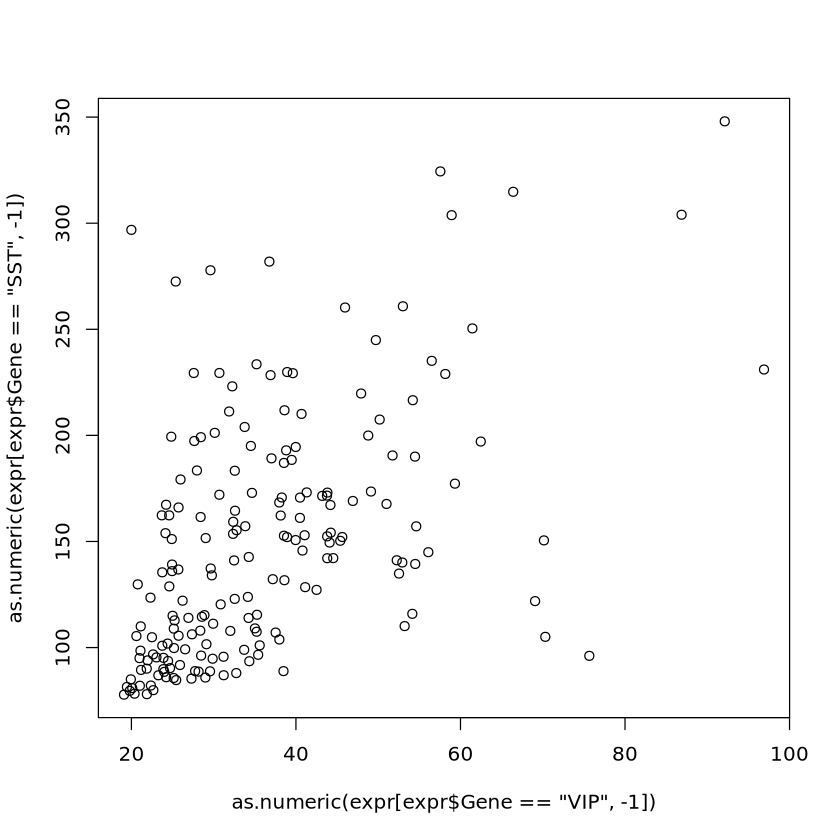

In [150]:
plot(as.numeric(expr[expr$Gene == "VIP", -1]), as.numeric(expr[expr$Gene == "SST", -1]))

In [105]:
expr[expr$Gene == "VIP", -1]

,GTEX.12126.0011.R10b.SM.5BC6T,GTEX.1F7RK.0011.R10b.SM.ARU7Y,GTEX.WHSE.0011.R10A.SM.EYYVG,GTEX.11ZUS.0011.R10b.SM.5BC79,GTEX.16YQH.0011.R10b.SM.7LT8U,GTEX.17HG3.0011.R10b.SM.7LT97,GTEX.1KWVE.0011.R10b.SM.F649A,GTEX.1PIIG.0011.R10a.SM.F2TB8,GTEX.1POEN.0011.R10b.SM.F647N,GTEX.11O72.0011.R10a.SM.H65ZU,⋯,GTEX.12WSF.0011.R10a.SM.5LZVH,GTEX.13N1W.0011.R10b.SM.5MR4H,GTEX.13SLW.0011.R10a.SM.5S2UI,GTEX.14E7W.0011.R10a.SM.5YYAX,GTEX.15DCD.0011.R10b.SM.6LPII,GTEX.15UF6.0011.R10b.SM.9OSVF,GTEX.1BAJH.0011.R10a.SM.7MXT9,GTEX.1H1ZS.0011.R10b.SM.A9SK9,GTEX.1IDJH.0011.R10a.SM.ARZLK,GTEX.1PWST.0011.R10a.SM.F2I37
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6538,86.87487,45.96963,58.92742,70.14492,92.12353,54.4739,38.93619,53.00262,56.50653,38.54107,⋯,35.0193,30.13231,21.88178,25.73114,23.69553,19.80201,59.32597,25.73362,32.48235,21.13417
